In [1]:
import os, re
import argparse

# import nest_asyncio
import numpy as np
import pandas as pd
import lightkurve as lk
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.io import fits
from tqdm import tqdm
from astrocut import CutoutFactory
# from ipywidgets import *
import matplotlib.colors as colors
from matplotlib import patches
from astropy.stats import sigma_clip
from glob import glob

from tess_asteroid_ml import *
from tess_asteroid_ml.make_TESS_asteroid_db import *
from tess_asteroid_ml.utils import in_cutout, power_find

import pickle
import warnings
warnings.simplefilter('ignore')

In [2]:
from tess_asteroid_ml.make_TESScut_asteroids import *

In [3]:
os.path.dirname(PACKAGEDIR)

'/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml'

In [4]:
def fit_bkg(tpf:lk.TessTargetPixelFile, polyorder:int=1) -> np.ndarray:
    """Fit a simple 2d polynomial background to a TPF
    
    Parameters
    ----------
    tpf: lightkurve.TessTargetPixelFile
        Target pixel file object
    polyorder: int
        Polynomial order for the model fit.
        
    Returns
    -------
    model : np.ndarray
        Model for background with same shape as tpf.shape
    """
    
    if not isinstance(tpf, lk.TessTargetPixelFile):
        raise ValueError("Input a TESS Target Pixel File")
    
    if (np.product(tpf.shape[1:]) < 100) | np.any(np.asarray(tpf.shape[1:]) < 6):
        raise ValueError("TPF too small. Use a bigger cut out.")
        
        
    # Grid for calculating polynomial
    R, C = np.mgrid[:tpf.shape[1], :tpf.shape[2]].astype(float)
    R -= tpf.shape[1]/2
    C -= tpf.shape[2]/2
    
    
    def func(tpf):
        # Design matrix
        A = np.vstack([R.ravel()**idx*C.ravel()**jdx for idx in range(polyorder + 1) for jdx in range(polyorder + 1)]).T
        
        # Median star image
        m = np.median(tpf.flux.value, axis=0)
        # Remove background from median star image
        mask = ~sigma_clip(m, sigma=3).mask.ravel()
        #plt.imshow(mask.reshape(m.shape))
        bkg0 = A.dot(np.linalg.solve(A[mask].T.dot(A[mask]), A[mask].T.dot(m.ravel()[mask]))).reshape(m.shape)
        
        m -= bkg0

        # Include in design matrix
        A = np.hstack([A, m.ravel()[:, None]])
        
        # Fit model to data, including a model for the stars
        f = np.vstack(tpf.flux.value.transpose([1, 2, 0]))
        ws = np.linalg.solve(A.T.dot(A), A.T.dot(f))
        
        # Build a model that is just the polynomial
        model = (A[:, :-1].dot(ws[:-1])).reshape((tpf.shape[1], tpf.shape[2], tpf.shape[0])).transpose([2, 0, 1])
        # model += bkg0
        return model
    
    # Break point for TESS orbit
    b = np.where(np.diff(tpf.cadenceno) == np.diff(tpf.cadenceno).max())[0][0] + 1
    
    # Calculate the model for each orbit, then join them
    model = np.vstack([func(tpf) for tpf in [tpf[:b], tpf[b:]]])
    return model

['https://archive.stsci.edu/missions/tess/ffi/s0004/2018/307/1-1/tess2018307065939-s0004-1-1-0124-s_ffic.fits']
Loading from CSV file: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/jpl/jpl_small_bodies_tess_s0004-1-0_catalog.csv
JPL SBI found 25424 asteroids with V < 30 in s0004-1-0
                   Object name Astrometric RA (hh:mm:ss)  \
0          23 Thalia (A852 XA)               02:17:25.72   
1          46 Hestia (A857 QA)               02:06:33.37   
2           307 Nike (A891 EB)               01:53:36.72   
3      318 Magdalena (A891 SA)               01:49:45.16   
4         381 Myrrha (A894 AC)               03:26:13.42   
...                        ...                       ...   
22430              (2018 XC20)               03:11:38.13   
22437               (2019 AX7)               02:37:47.20   
25391               (2023 RJ4)               03:28:25.45   
25409                243P/NEAT               01:52:15.73   
25421    P/2015 M2 (PANSTARRS)               0

4113


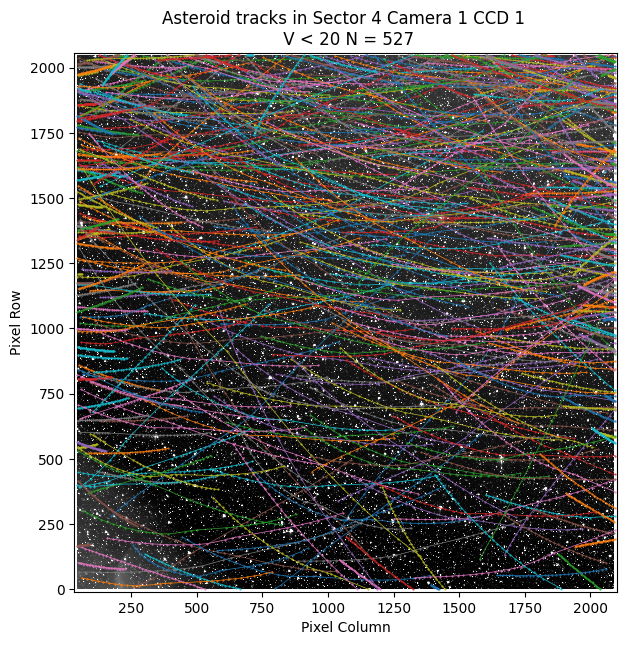

[[  34   93  152 ... 1863 1922 1981]
 [  34   93  152 ... 1863 1922 1981]
 [  34   93  152 ... 1863 1922 1981]
 ...
 [  34   93  152 ... 1863 1922 1981]
 [  34   93  152 ... 1863 1922 1981]
 [  34   93  152 ... 1863 1922 1981]] [[  34   34   34 ...   34   34   34]
 [  93   93   93 ...   93   93   93]
 [ 152  152  152 ...  152  152  152]
 ...
 [1863 1863 1863 ... 1863 1863 1863]
 [1922 1922 1922 ... 1922 1922 1922]
 [1981 1981 1981 ... 1981 1981 1981]] (34, 34)


In [51]:
sector, camera, ccd = 4, 1, 1
provider = "mast"
maglim = 20

ffi_file = get_FFI_name(sector=sector, camera=camera, ccd=ccd, provider=provider, correct=False)
print(ffi_file)

# get FFI data to build ra/dec coordinates for later query

ffi_header, f2d, col_2d, row_2d, ra_2d, dec_2d = get_data_from_files(
    ffi_file, provider=provider
)
ffi_header = ffi_header[0]
f2d = f2d[0]
col_2d = col_2d
row_2d = row_2d
ra_2d = ra_2d[0]
dec_2d = dec_2d[0]

obs_time = Time([ffi_header["DATE-OBS"], ffi_header["DATE-END"]], format="isot")

jpl_df = get_asteroid_table(
    SkyCoord(ra_2d.min() * u.deg, dec_2d.min() * u.deg, frame='icrs'),
    SkyCoord(ra_2d.max() * u.deg, dec_2d.max() * u.deg, frame='icrs'),
    sector=sector,
    camera=camera,
    ccd=0,
    date_obs=obs_time.mean().jd,
)
if maglim <= 30:
    asteroid_df = jpl_df.query(f"V_mag <= {maglim}")
print(asteroid_df)

sb_ephems_lowres = read_asteroid_db(
    asteroid_df, low_res=True, sector=sector, camera=camera, ccd=ccd
)
print(len(sb_ephems_lowres))

vlo, lo, mid, hi, vhi = np.nanpercentile(f2d, [0.2, 3, 50, 95, 99])
cnorm = colors.LogNorm(vmin=lo, vmax=vhi)

plt.figure(figsize=(7,7))
plt.pcolormesh(col_2d, row_2d, f2d, norm=cnorm, cmap="Greys_r")

counter = 0
for k, val in sb_ephems_lowres.items():
    if len(val) == 0:
        continue
    val = val.query(f"camera == {camera} and ccd == {ccd}")
    if len(val) > 0: counter += 1
    plt.plot(val.column, val.row, ".-", ms=1., lw=.5)
    # if k == 1: break
plt.title(f"Asteroid tracks in Sector {sector} Camera {camera} CCD {ccd} \n "
          f"V < {maglim} N = {counter}")

plt.xlim(col_2d.min() - 10, col_2d.max() + 10)
plt.ylim(row_2d.min() - 10, row_2d.max() + 10)
# plt.gca().set_aspect('equal')
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.show()

cutout_size = 64
xcen, ycen = get_cutout_centers(sampling="tiled", overlap=5, size=cutout_size)
print(xcen, ycen, xcen.shape)

sb_ephems_highres = {}

download = True
fficuts_list = []

In [ ]:
nrow, i = 0, ycen[1:, 0][0]

cut_dict = {}
for j in xcen[0, 1:8]:
    # if not (j < 200 or j > 1800):
    #     continue
    cut_dict[f"c{col_2d[i, j]:04}_r{row_2d[i,j]:04}"] = SkyCoord(
        ra_2d[i, j] * u.deg, dec_2d[i, j] * u.deg, frame="icrs"
    )
    # if j > 1000: break


In [28]:
cut_dict

{'c0137_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (48.64674193, -37.95923824)>,
 'c0196_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (48.34147719, -38.15959933)>,
 'c0255_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (48.03341389, -38.3603039)>,
 'c0314_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (47.72255172, -38.56130362)>,
 'c0373_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (47.40889092, -38.76254999)>,
 'c0432_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (47.09243231, -38.96399442)>,
 'c0491_r0093': <SkyCoord (ICRS): (ra, dec) in deg
     (46.77317732, -39.16558818)>}

In [29]:
tpf_names_astrocut = get_cutouts_astrocut(
                cut_dict,
                sector=sector,
                cam_ccd=f"{camera}-{ccd}",
                cutout_size=cutout_size,
            )
tpf_names_astrocut

['/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0137_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0196_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0255_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0314_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0373_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0432_r0093_64x64pix.fits',
 '/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0491_r0093_64x64pix.fits']

In [9]:
tpf_names_rip = get_cutouts_tessrip(
                cut_dict,
                sector=sector,
                cam_ccd=f"{camera}-{ccd}",
                cutout_size=cutout_size,
            )

Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0137_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0196_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0255_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0314_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0373_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0432_r0093_64x64pix_rip.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0003/TESScut_s0003-3-1_c0491_r0093_64x64pix_rip.fits


In [10]:
tpf_astrocut = lk.read(tpf_names_astrocut[0], quality_bitmask=None)
tpf_rip = lk.read(tpf_names_rip[0], quality_bitmask=None)

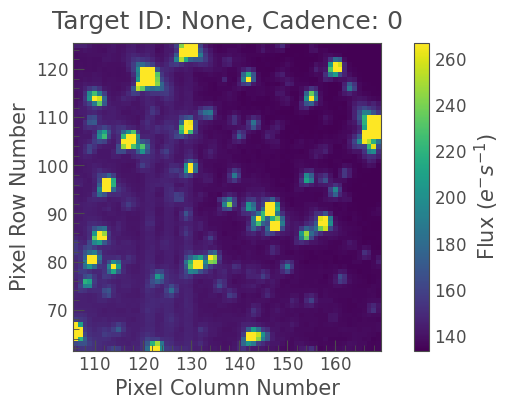

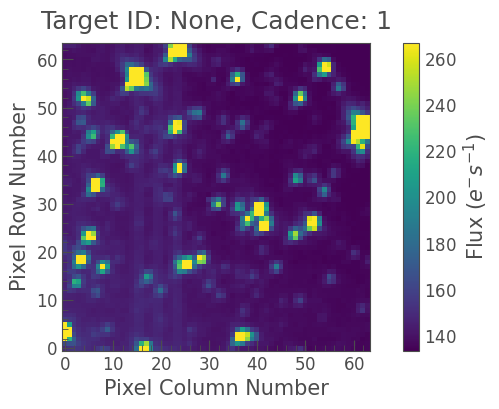

In [11]:
tpf_astrocut.plot()
plt.show()

tpf_rip.plot()
plt.show()

In [15]:
tpf_astrocut.shape, tpf_astrocut.column, tpf_astrocut.row

((1288, 64, 64), 106, 62)

In [47]:
tpf_astrocut.cadenceno, tpf_astrocut.time.btjd

(array([   0,    1,    2, ..., 1285, 1286, 1287]),
 array([1382.05532425, 1382.07615805, 1382.09699185, ..., 1409.32642295,
        1409.34725621, 1409.36808947]))

In [27]:
tpf_rip.shape, tpf_rip.column, tpf_rip.row

((1288, 64, 64), 0, 0)

In [34]:
tpf_rip.cadenceno, tpf_rip.time.jd

(array([   1,    2,    3, ..., 1310, 1311,    0], dtype='>i2'),
 array([1382.05532425, 1382.07615805, 1382.09699185, ..., 1409.32642295,
        1409.34725621, 1409.36808947]))

In [13]:
tpf_astrocut.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 48.646014428976  -37.956681605987  
CRPIX : 32.710362031141  32.536943432551  
PC1_1 PC1_2  : -0.004060666976372  0.0037590416219044  
PC2_1 PC2_2  : -0.0033926095758231  -0.0037333466169151  
CDELT : 1.0  1.0  
NAXIS : 64  64

In [12]:
tpf_rip.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 48.232253726778  -44.837891823251  
CRPIX : 1045.0  1001.0  
PC1_1 PC1_2  : -0.0042709038647725  0.0038905602669214  
PC2_1 PC2_2  : -0.003782903602078  -0.0041748339101775  
CDELT : 1.0  1.0  
NAXIS : 64  64

In [30]:
fficut_aster = AsteroidTESScut(lk.read(tpf_names_astrocut[0], quality_bitmask=None))
fficut_aster.ffi_exp_time = (ffi_header["TSTOP"] - ffi_header["TSTART"]) * 24 * 3600
fficut_aster.get_CBVs(align=False, interpolate=True)
fficut_aster.get_quaternions_and_angles()
if fit_bkg:
    # print("median: ",np.median(fficut_aster.flux), "min: ", fficut_aster.flux.min())
    fficut_aster.fit_background(polyorder=3, positive_flux=True)
    # print("median: ",np.median(fficut_aster.flux), "min: ", fficut_aster.flux.min())

for k, val in sb_ephems_lowres.items():
    if len(val) == 0:
        continue
    # check if asteroid track passes over the TESScut
    is_in = in_cutout(
        fficut_aster.column,
        fficut_aster.row,
        sb_ephems_lowres[k].column.values,
        sb_ephems_lowres[k].row.values,
    )
    if is_in:
        # print(
        #     f"({k}) Asteroid in cutout: ", asteroid_df.loc[k, "name"]
        # )
        # load full res track
        if k not in sb_ephems_highres.keys():
            sb_ephems_highres.update(read_asteroid_db(
                asteroid_df.loc[[k]],
                low_res=False,
                sector=sector,
                camera=camera,
                ccd=ccd,
                quiet=True,
            ))
        source_rad = 3.2e2 / (sb_ephems_highres[k].vmag.mean()) ** 1.8
        fficut_aster.get_asteroid_mask(
            sb_ephems_highres[k],
            name=asteroid_df.loc[k, ["Object name", "V_mag"]],
            mask_type="circular",
            mask_radius=source_rad,
            mask_num_type="dec",
        )

In [31]:
fficut_aster.find_orbit_breaks()

In [32]:
fficut_aster.shape

'N times, N pixels: (1077, 4096)'

In [33]:
fficut_aster.breaks

array([  21, 1047])

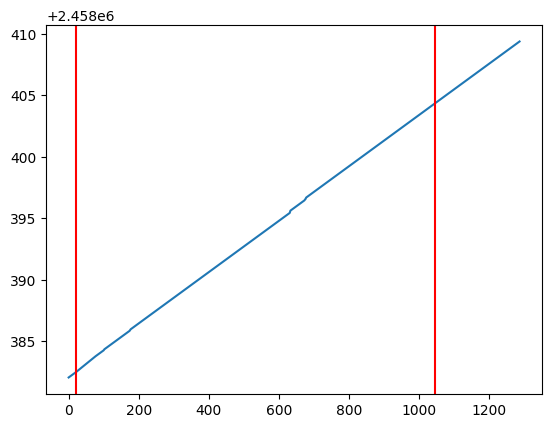

In [42]:
plt.plot(fficut_aster.cadenceno[fficut_aster.quality_mask], fficut_aster.time)
plt.axvline(fficut_aster.breaks[0], c="r")
plt.axvline(fficut_aster.breaks[1], c="r")
plt.show()

In [47]:
dts = np.diff(fficut_aster.time)
np.sort(dts)[::-1][:10]

array([2.29166184, 1.1875268 , 0.18750181, 0.12500235, 0.12500143,
       0.1041666 , 0.08333508, 0.08333429, 0.08333363, 0.08333306])

In [10]:
[x.shape for x in TIME]

[(337,), (106,), (579,)]

In [ ]:
[np.diff(x).max() for x in TIME]

In [ ]:
[(x.asteroid_mask_2d != 0).sum()/(x.npixels * x.ntimes)*100 for x in fficuts_list]

In [16]:
[len(x.asteroid_names) for x in fficuts_list if hasattr(x, "asteroid_names")]

[1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 3, 2, 1, 2, 1, 1, 1, 1]

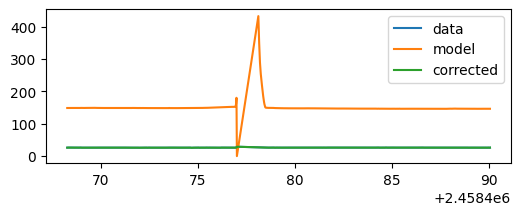

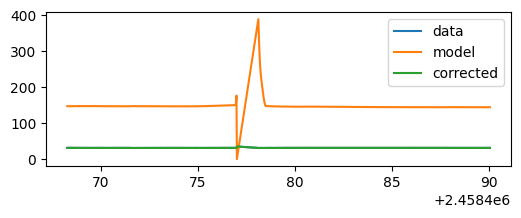

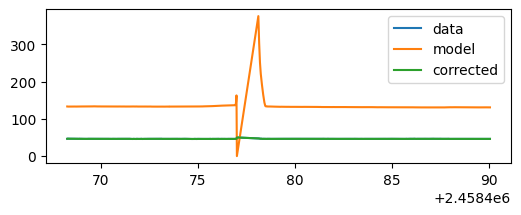

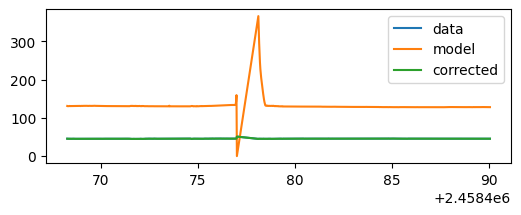

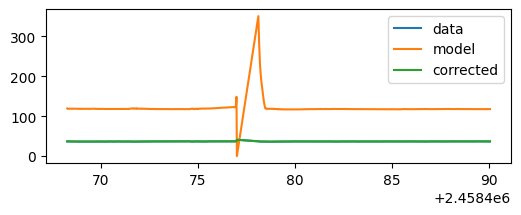

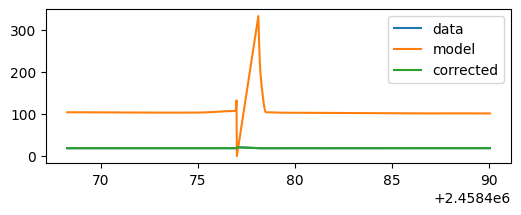

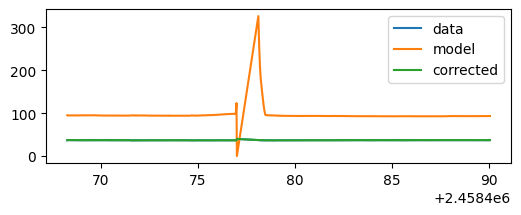

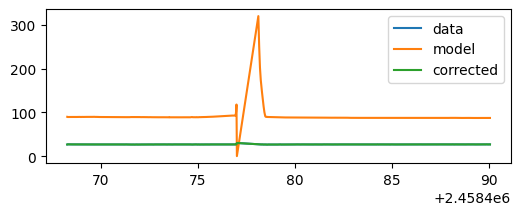

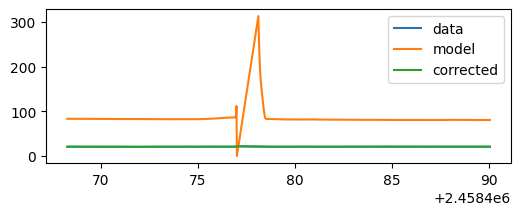

In [123]:
for obj in fficuts_list:
    plt.figure(figsize=(6,2))
    plt.plot(obj.time, np.median(obj.flux, axis=1), label="data")
    plt.plot(obj.time, np.median(np.median(obj.bkg_model, axis=1), axis=1), label="model")
    plt.plot(obj.time, np.median(obj.flux, axis=1), label="corrected")
    plt.legend()
    plt.show()

In [104]:
fficut_aster = fficuts_list[1]

In [105]:
fficut_aster.asteroid_mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [106]:
time_idx = np.unique(np.hstack([x for x in fficut_aster.asteroid_time_idx.values()]))
time_idx

array([261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273,
       274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285, 286,
       287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299,
       300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312,
       313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325,
       326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338,
       339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351,
       352, 353, 354, 355, 356, 357, 358])

In [107]:
fficut_aster.shape

'N times, N pixels: (981, 4096)'

In [108]:
fit_bkg(fficut_aster.tpf, polyorder=3).shape

(981, 64, 64)

In [109]:
bkg_model = fit_bkg(fficut_aster.tpf, polyorder=3)
img_frame = (fficut_aster.flux_2d - bkg_model) 
img_frame += np.abs(np.floor(np.min(img_frame)))

In [110]:
np.median(img_frame), np.mean(img_frame), img_frame.min()

(13.16857446267074, 53.156600610386675, 0.05165805553849623)

In [111]:
fficut_aster.fit_background(polyorder=3, positive_flux=True)

In [112]:
np.median(fficut_aster.flux), np.mean(fficut_aster.flux), fficut_aster.flux.min()

(13.168574, 53.1566, 0.051657677)

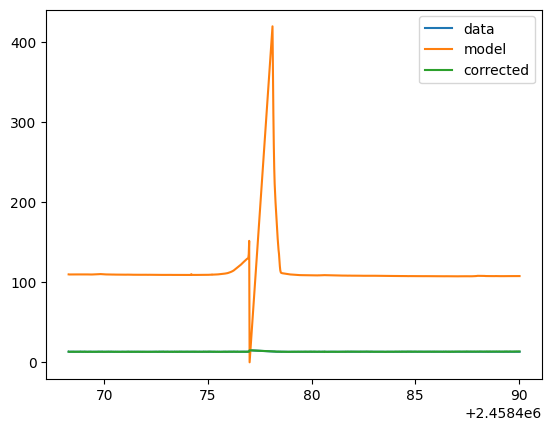

In [113]:
plt.plot(fficut_aster.time, np.median(fficut_aster.flux, axis=1), label="data")
plt.plot(fficut_aster.time, np.median(np.median(bkg_model, axis=1), axis=1), label="model")
plt.plot(fficut_aster.time, np.median(np.median(img_frame, axis=1), axis=1), label="corrected")
plt.legend()
plt.show()

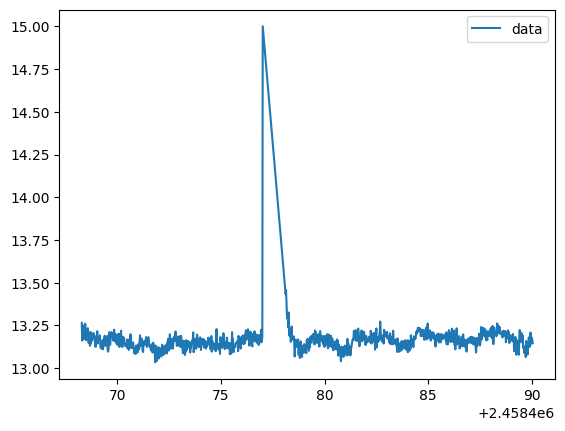

In [118]:
plt.plot(fficut_aster.time, np.median(fficuts_list[1].flux, axis=1), label="data")
# plt.plot(fficut_aster.time, np.median(np.median(fficut_aster.bkg_model, axis=1), axis=1), label="model")
# plt.plot(fficut_aster.time, np.median(fficut_aster.flux, axis=1), label="corrected")
plt.legend()
plt.show()

In [24]:
pers = [1, 70, 97, 99.8]
np.nanpercentile(img_frame, pers)

array([  1.73353328,  12.93834698, 113.36170106, 840.68378038])